In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 84 (delta 27), reused 32 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 3.15 MiB | 6.34 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [2]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

--2026-09-06 17:59:14--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  35.0MB/s    in 2.3s    

2026-09-06 17:59:16 (35.0 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]



In [5]:
import os
from pathlib import Path
import numpy as np
import torch
from skimage.io import imread
from skimage.transform import resize

IMG_SIZE = 128

class BBBC038Dataset(Dataset):
    def __init__(self):
        self.train_dir = Path("data/stage1_train")
        self.ids = os.listdir(self.train_dir)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id = self.ids[idx]
        self.mask_dir = self.train_dir / id / "masks"
        img_path = self.train_dir / id / "images" / f"{id}.png"
        image = imread(img_path)[..., :3] / 255
        masks = [imread(self.mask_dir / f) for f in os.listdir(self.mask_dir)]
        mask = np.max(masks, axis=0) / 255

        image = resize(image, (IMG_SIZE, IMG_SIZE), preserve_range=True)
        mask = resize(mask, (IMG_SIZE, IMG_SIZE), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        image = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        mask = torch.from_numpy(mask[..., None]).permute(2, 0, 1)[0].contiguous().float()

        return image, mask

In [6]:
dataset = BBBC038Dataset()
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15])

In [7]:
# Treinando a ResUNet no BBBC038

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.7298418283462524
0/5 - loss=0.6248603463172913
0/10 - loss=0.569310188293457
0/15 - loss=0.49990275502204895
0/20 - loss=0.4868033826351166
0/25 - loss=0.3832886219024658
1/0 - loss=0.4641956686973572
1/5 - loss=0.35866644978523254
1/10 - loss=0.27492189407348633
1/15 - loss=0.23480544984340668
1/20 - loss=0.25981074571609497
1/25 - loss=0.28931182622909546
2/0 - loss=0.2351059764623642
2/5 - loss=0.17705224454402924
2/10 - loss=0.20366984605789185
2/15 - loss=0.22465643286705017
2/20 - loss=0.2200937569141388
2/25 - loss=0.17161566019058228
3/0 - loss=0.19929799437522888
3/5 - loss=0.20082367956638336
3/10 - loss=0.22016863524913788
3/15 - loss=0.2025851011276245
3/20 - loss=0.17396801710128784
3/25 - loss=0.160541832447052
4/0 - loss=0.12831240892410278
4/5 - loss=0.1564260721206665
4/10 - loss=0.13075968623161316
4/15 - loss=0.2323339730501175
4/20 - loss=0.18105101585388184
4/25 - loss=0.17822566628456116


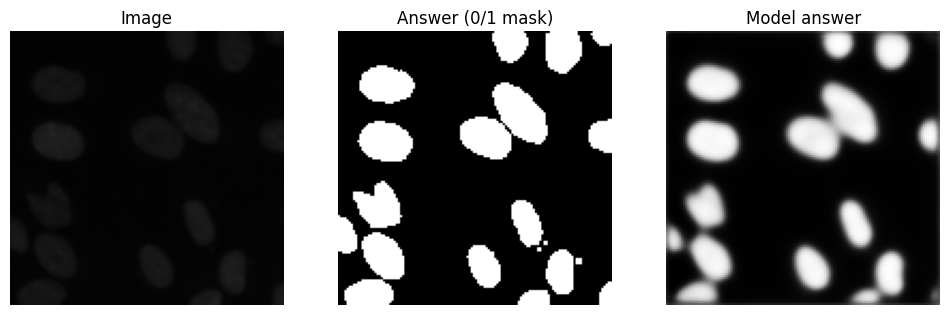

In [8]:
# Verificando a saída do modelo

model.eval()

for img, mask in DataLoader(test_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")


    plt.show()

    break

In [9]:
# computa o IoU e Dice no conjunto de treino

model.eval()

thresholds = torch.arange(0, 1, .05)
iou_scores, dice_scores = [], []

with torch.no_grad():
    for x, y in DataLoader(test_dataset, pin_memory=True):
        y_hat = F.sigmoid(model(x.to(device, non_blocking=True))[0]).cpu()

        iou_scores.append([utils.iou_score(1 * (y_hat > th), y) for th in thresholds])

        dice_scores.append([utils.dice_score(1 * (y_hat > th), y) for th in thresholds])

iou_scores = torch.tensor(iou_scores, dtype=torch.float32).mean(dim=0)
dice_scores = torch.tensor(dice_scores, dtype=torch.float32).mean(dim=0)




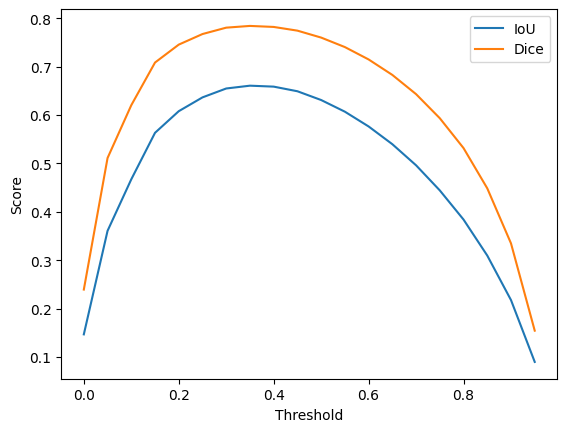

In [10]:
plt.plot(thresholds, iou_scores, label='IoU')
plt.plot(thresholds, dice_scores, label='Dice')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

In [11]:
def probability_to_instances(probability, threshold=0.5):

    binary_mask = (probability >= threshold).astype(np.uint8)

    number_of_labels, instance_map = cv2.connectedComponents(
        binary_mask,
        connectivity=8
    )

    return instance_map.astype(np.int32)

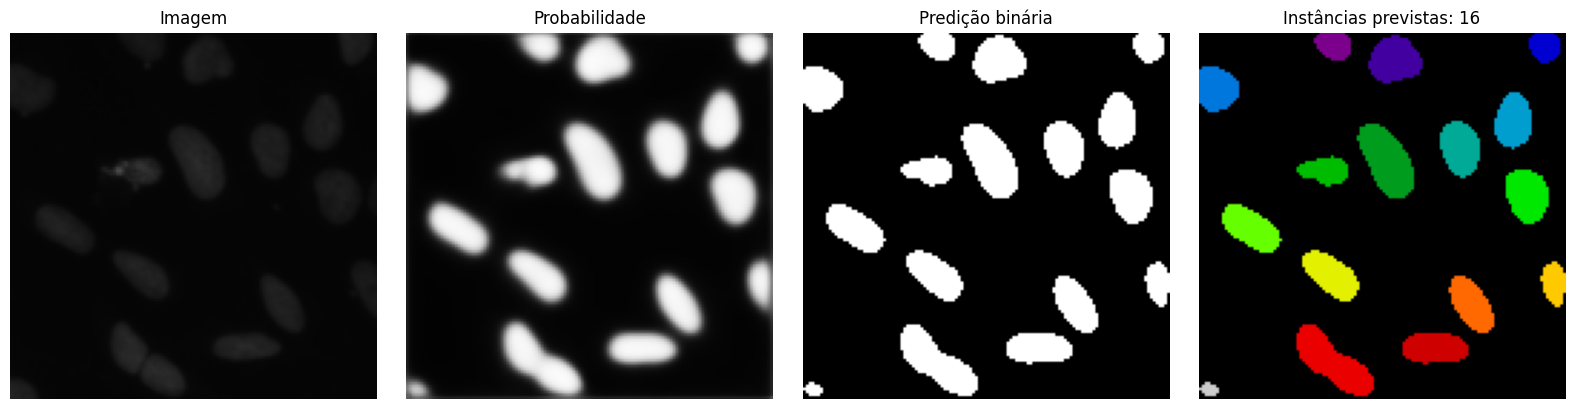

In [12]:
model.eval()

with torch.no_grad():
    for img, mask in DataLoader(test_dataset, shuffle=True):
        img_device = img.to(device)

        probability = torch.sigmoid(
            model(img_device)
        )[0, 0].cpu().numpy()

        pred_instance_map = probability_to_instances(
            probability,
            threshold=0.5
        )

        binary_prediction = probability >= 0.5
        n_pred = pred_instance_map.max()

        image = img[0].permute(1, 2, 0).numpy()
        ground_truth = mask[0].numpy()

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        axes[0].imshow(image)
        axes[0].set_title("Imagem")

        axes[1].imshow(probability, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Probabilidade")

        axes[2].imshow(binary_prediction, cmap="gray")
        axes[2].set_title("Predição binária")

        axes[3].imshow(pred_instance_map, cmap="nipy_spectral")
        axes[3].set_title(f"Instâncias previstas: {n_pred}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        break

In [14]:
class InstanceEvaluationSubset(Dataset):
    def __init__(self, original_dataset, indices):
        self.original_dataset = original_dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        original_index = self.indices[position]

        image, semantic_mask = self.original_dataset[original_index]

        image_id = self.original_dataset.ids[original_index]
        mask_dir = (
            self.original_dataset.train_dir
            / image_id
            / "masks"
        )

        instance_map = np.zeros(
            (IMG_SIZE, IMG_SIZE)
        )

        mask_files = sorted(os.listdir(mask_dir))

        for instance_id, mask_file in enumerate( mask_files, start=1):
            instance_mask = imread( mask_dir/mask_file) > 0

            instance_mask = resize( instance_mask.astype(np.uint8), (IMG_SIZE, IMG_SIZE),
                order=0,
                preserve_range=True,
                anti_aliasing=False
            ).astype(bool)

            instance_map[instance_mask] = instance_id

        instance_map = torch.from_numpy(
            instance_map
        ).long()

        return (
            image,
            semantic_mask,
            instance_map,
            image_id
        )




In [16]:
instance_test_dataset = InstanceEvaluationSubset(
    original_dataset=dataset,
    indices=test_dataset.indices
)

instance_test_loader = DataLoader(
    instance_test_dataset,
    batch_size=1,
    shuffle=False
)

print(instance_test_loader)

ID: 29ea4f6eb4545f43868a9b40a60000426bf8dfd9d062546656a37bd2a2aaf9ec
Número de instancias GT: 13


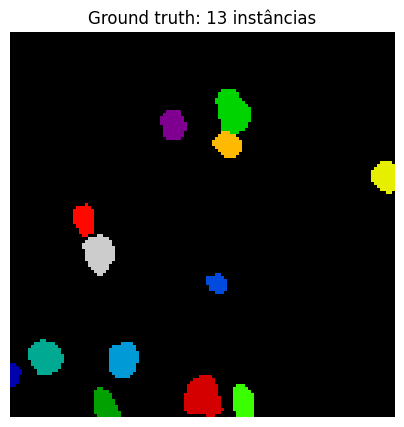

In [17]:
image, semantic_mask, instance_map, image_id = next(
    iter(instance_test_loader)
)

print("ID:", image_id[0])
print("Número de instancias GT:", instance_map.max().item())

plt.figure(figsize=(5, 5))
plt.imshow(instance_map[0], cmap="nipy_spectral")
plt.title(f"Ground truth: {instance_map.max().item()} instâncias")
plt.axis("off")
plt.show()